In [ ]:
!pip install ultralytics -q
!pip install supervision -q
!pip install ultralytics supervision -q
!pip install torch torchvision --upgrade -q

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO
from sklearn.cluster import KMeans
from scipy.ndimage import gaussian_filter
from IPython.display import Image as IPImage, HTML
from kaggle_secrets import UserSecretsClient
import base64
import uuid
import shutil

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [5]:
base = '/kaggle/input/datasets/saberghaderi/-dfl-bundesliga-460-mp4-videos-in-30sec-csv/DFL Bundesliga Data Shootout/train'

premier_dossier = os.path.join(base, 'B1606b0e6_1')
videos = os.listdir(premier_dossier)
print(f"{len(videos)} vidéos")
print(videos[:5])

92 vidéos
['B1606b0e6_1 (44).mp4', 'B1606b0e6_1 (45).mp4', 'B1606b0e6_1 (81).mp4', 'B1606b0e6_1 (92).mp4', 'B1606b0e6_1 (28).mp4']


In [6]:
VIDEO_PATH = os.path.join(base, 'B1606b0e6_1', 'B1606b0e6_1 (31).mp4')

# Vérification
print(f"Fichier existe : {os.path.exists(VIDEO_PATH)}")
print(f"Chemin : {VIDEO_PATH}")

Fichier existe : True
Chemin : /kaggle/input/datasets/saberghaderi/-dfl-bundesliga-460-mp4-videos-in-30sec-csv/DFL Bundesliga Data Shootout/train/B1606b0e6_1/B1606b0e6_1 (31).mp4


In [9]:
# Charger le modèle pré-entraîné sur COCO
model = YOLO('yolov8x.pt')  # x = extra-large, le plus précis

cap = cv2.VideoCapture(VIDEO_PATH)

# Lire juste la première frame
ret, frame = cap.read()
cap.release()



0: 384x640 27 persons, 62.1ms
Speed: 2.4ms preprocess, 62.1ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
Détections :
  person : 0.81
  person : 0.80
  person : 0.79
  person : 0.79
  person : 0.78
  person : 0.78
  person : 0.77
  person : 0.77
  person : 0.76
  person : 0.75
  person : 0.74
  person : 0.73
  person : 0.73
  person : 0.73
  person : 0.72
  person : 0.70
  person : 0.69
  person : 0.68
  person : 0.67
  person : 0.66
  person : 0.65
  person : 0.64
  person : 0.63
  person : 0.60
  person : 0.54
  person : 0.47
  person : 0.43


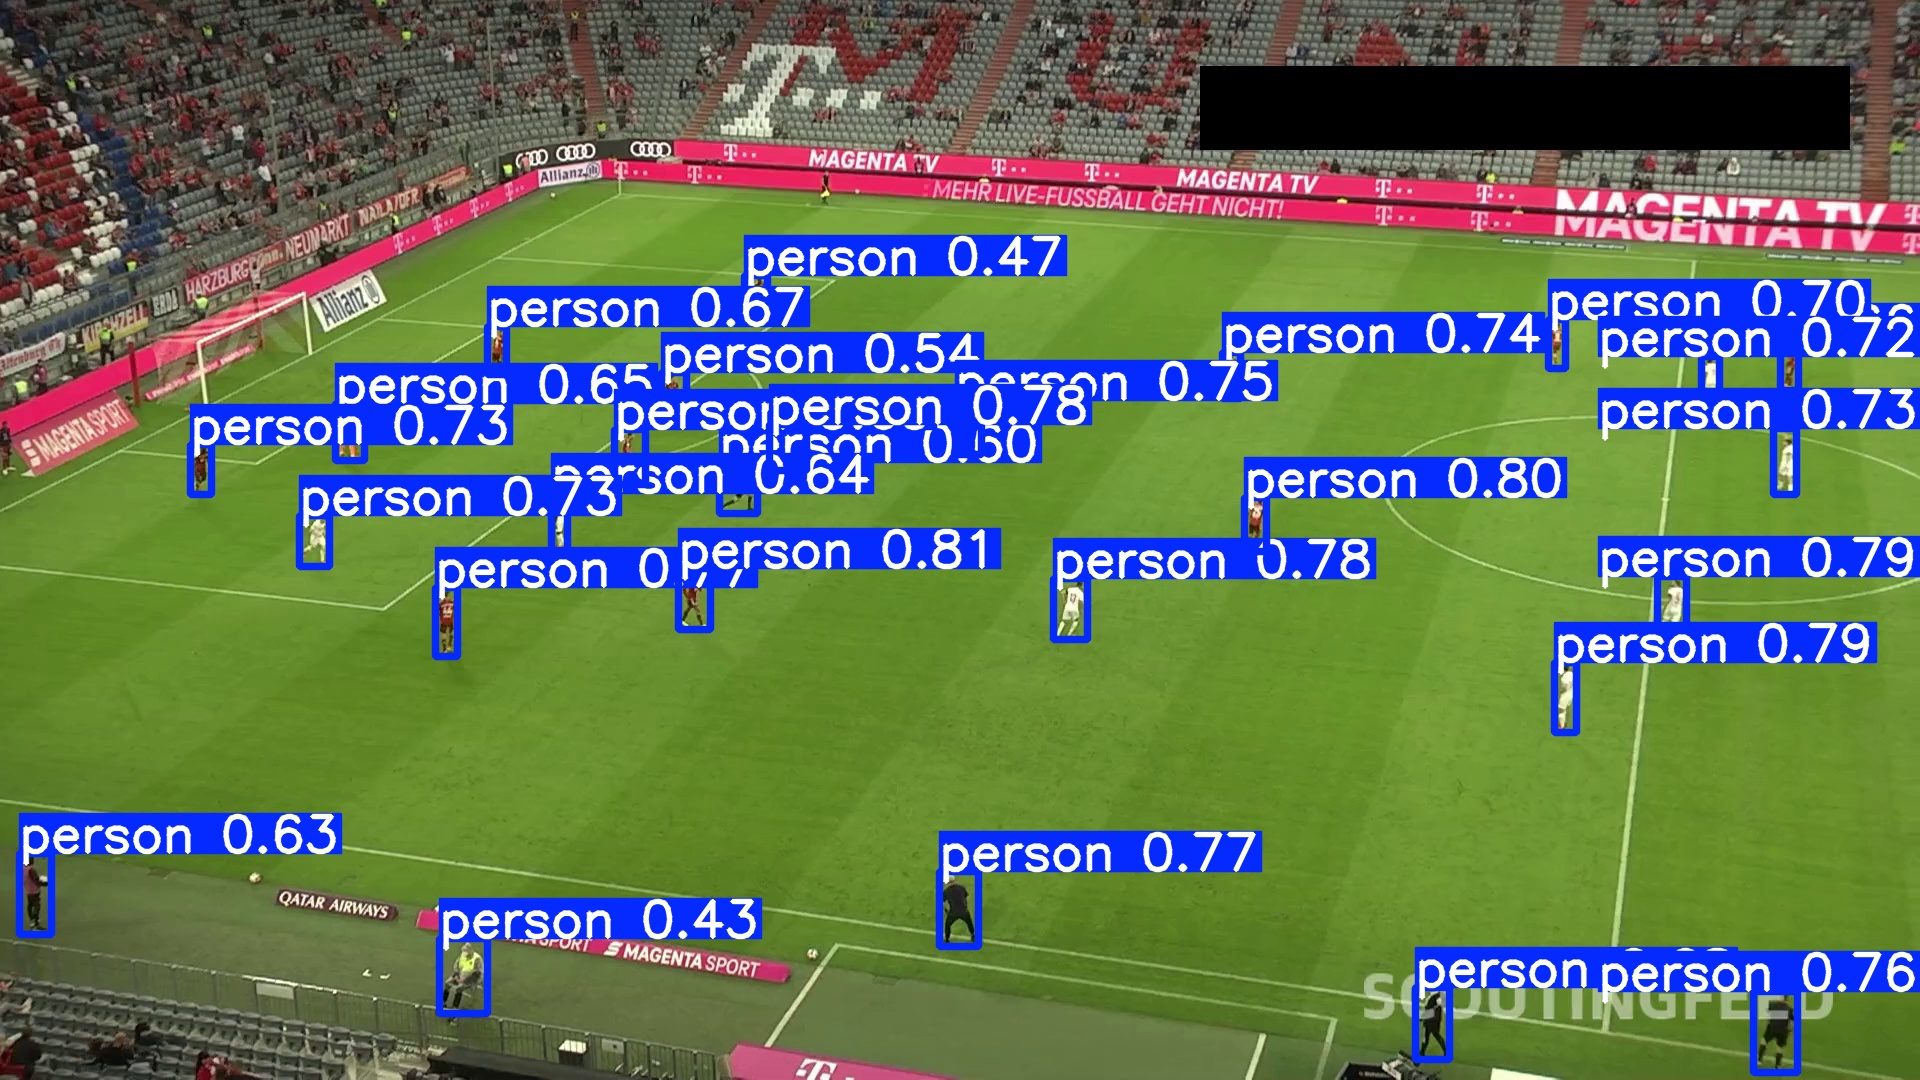

In [10]:

results = model(frame)

# Dessiner les boîtes sur la frame
annotated_frame = results[0].plot()

output_path = '/kaggle/working/test_detection.jpg'
cv2.imwrite(output_path, annotated_frame)

print("Détections :")
for box in results[0].boxes:
    classe = results[0].names[int(box.cls)]
    confiance = float(box.conf)
    print(f"  {classe} : {confiance:.2f}")


IPImage(output_path)

/tmp/ipykernel_48/979050777.py:4: FutureWarning: The `ByteTrack` was deprecated since v0.28.0. It will be removed in v0.31.0.
  tracker = sv.ByteTrack()


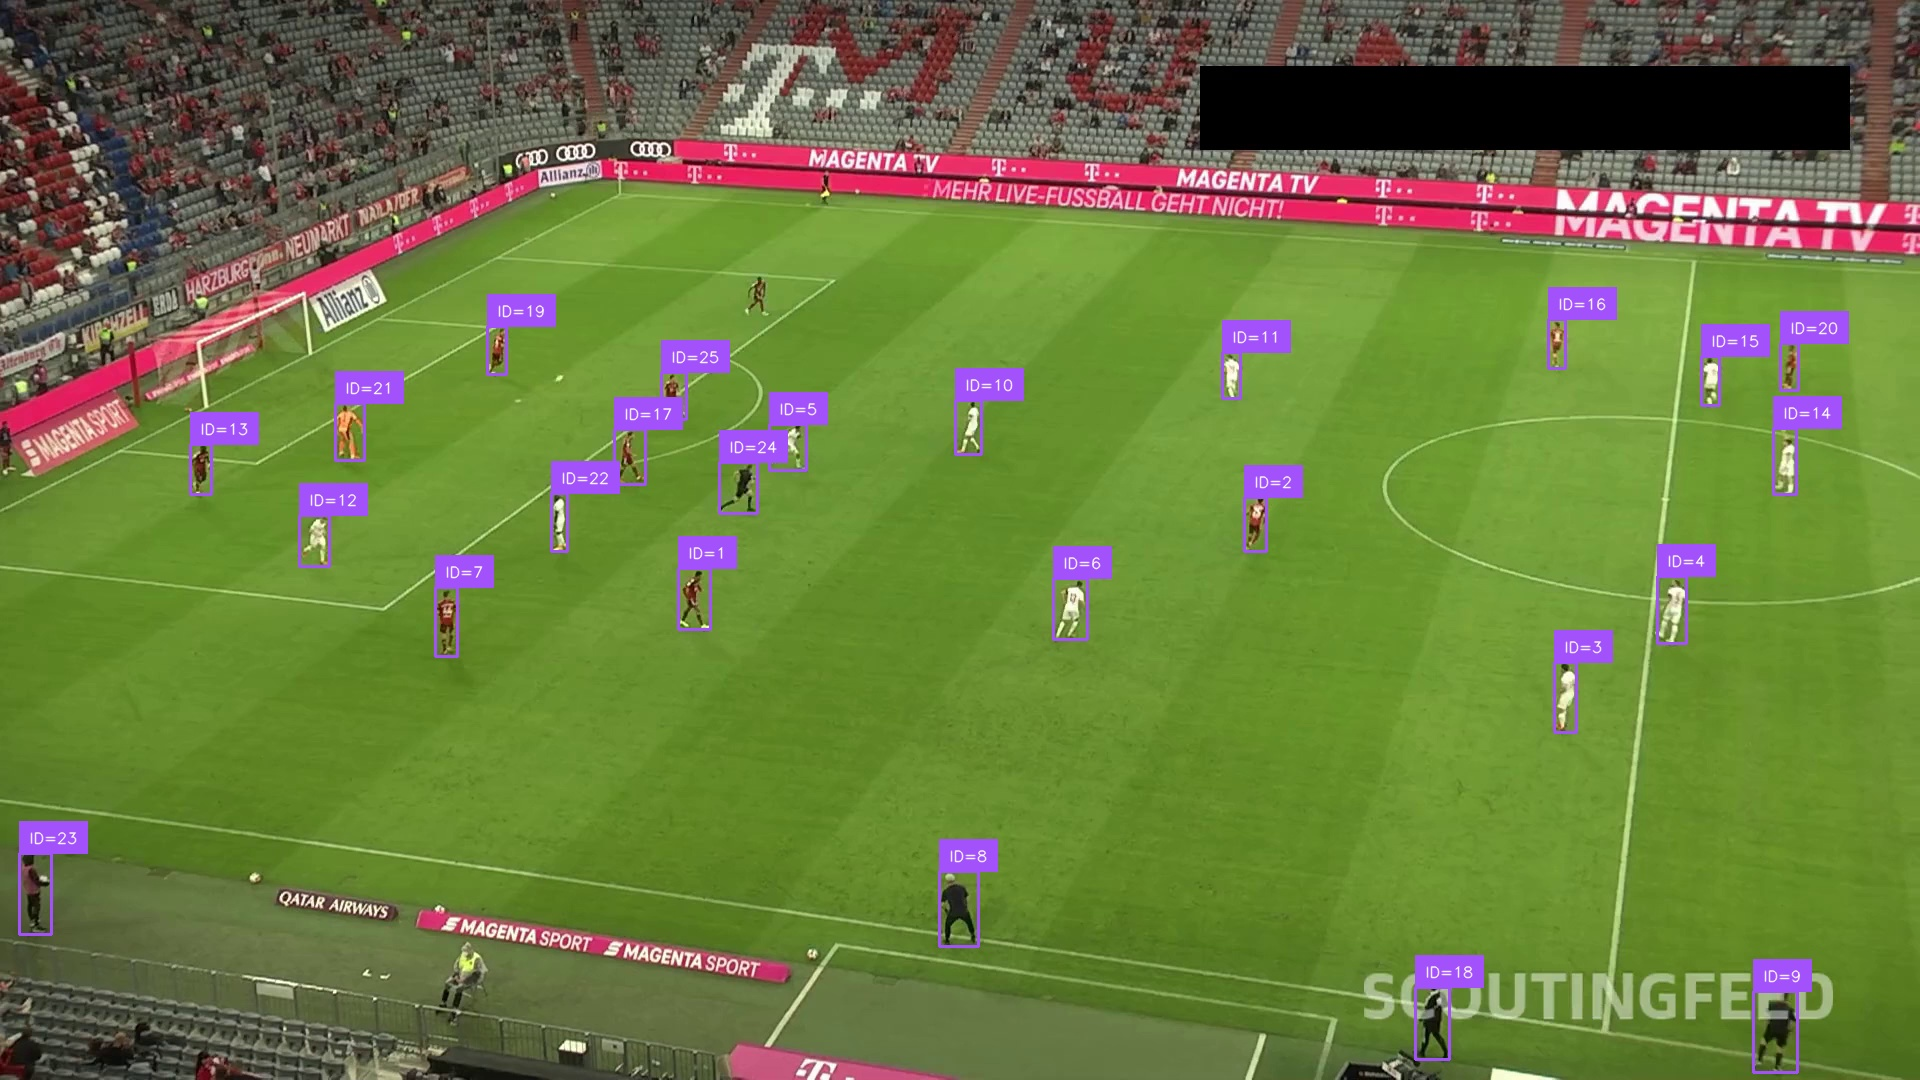

In [11]:
model = YOLO('yolov8x.pt')


tracker = sv.ByteTrack()


box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()


results = model(frame, conf=0.5, verbose=False)[0]


detections = sv.Detections.from_ultralytics(results)

# Filtrer uniquement les personnes (classe 0 dans COCO)
detections = detections[detections.class_id == 0]

# ByteTrack assigne les IDs
detections = tracker.update_with_detections(detections)

# Annoter
labels = [f"ID={tid}" for tid in detections.tracker_id]
annotated = box_annotator.annotate(frame.copy(), detections)
annotated = label_annotator.annotate(annotated, detections, labels)

cv2.imwrite('/kaggle/working/test_tracking.jpg', annotated)

from IPython.display import Image as IPImage
IPImage('/kaggle/working/test_tracking.jpg')

In [12]:
pts_image = np.array([
    [515, 241],   #coin surface haut-droit
    [125, 223],   #coin surface haut-gauche
    [157, 385],   #point de penalty
    [1421, 449],  #centre du rond central
], dtype=np.float32)

pts_terrain = np.array([
    [16.5, 13.84],
    [0,    13.84],
    [11,   34],
    [52.5, 34],
], dtype=np.float32)

H, _ = cv2.findHomography(pts_image, pts_terrain)
print(H)

[[    0.06031     0.11946     -34.179]
 [  -0.012189     0.27699     -38.945]
 [-7.0407e-05   0.0024568           1]]


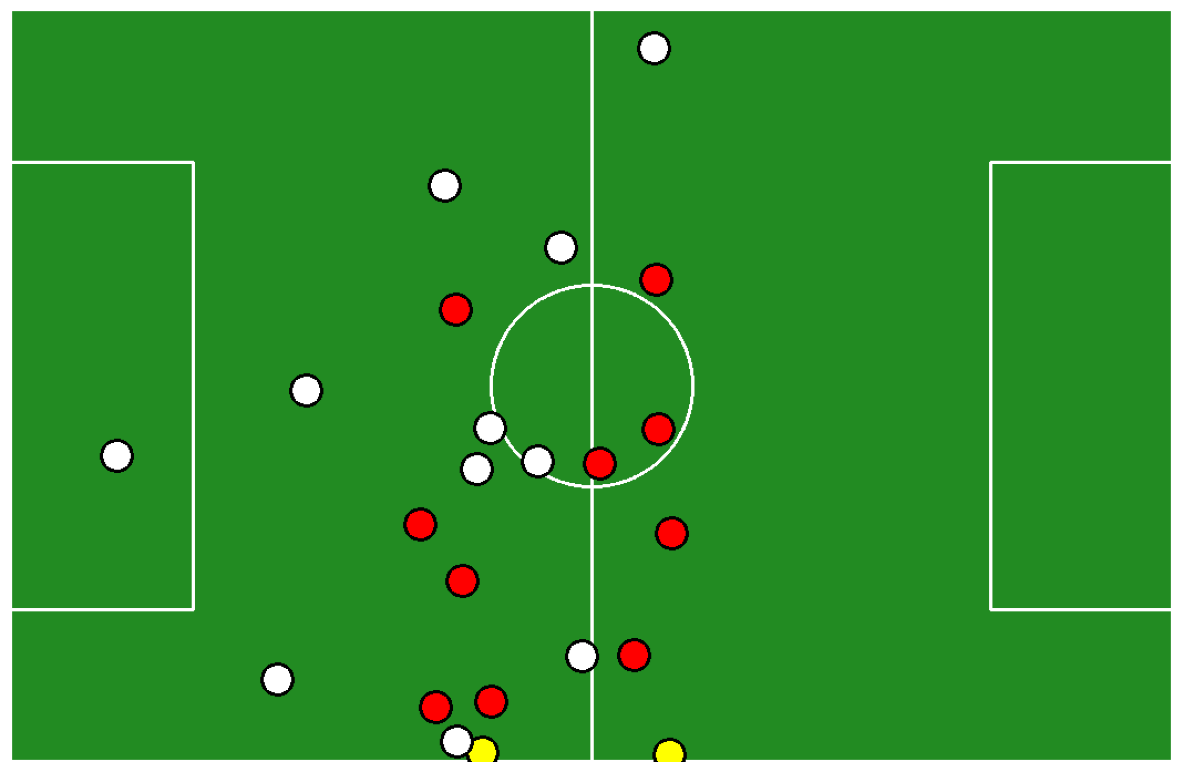

In [13]:
def get_jersey_color_hsv(frame, box):
    x1, y1, x2, y2 = map(int, box)
    h = y2 - y1
    w = x2 - x1
    crop = frame[y1 + int(h*0.1) : y1 + int(h*0.4),
                 x1 + int(w*0.15) : x2 - int(w*0.15)]
    if crop.size == 0:
        return [0, 0, 0]
    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV).reshape(-1, 3).astype(np.float32)
    mask = ~((hsv[:,0] > 35) & (hsv[:,0] < 85) & (hsv[:,1] > 40))
    filtered = hsv[mask]
    if len(filtered) < 5:
        return hsv.mean(axis=0)
    return filtered.mean(axis=0)

model = YOLO('yolov8x.pt')
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 375)
ret, frame = cap.read()
cap.release()

results = model(frame, conf=0.3, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)
detections = detections[detections.class_id == 0]

colors = np.array([get_jersey_color_hsv(frame, box) for box in detections.xyxy])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(colors)

# Couleurs pour la mini-carte : rouge, blanc, jaune (arbitre)
dot_colors = {0: (0,0,255), 1: (255,255,255), 2: (0,255,255)}

# Mini-carte
PITCH_W, PITCH_H = 1050, 680
pitch = np.zeros((PITCH_H, PITCH_W, 3), dtype=np.uint8)
pitch[:] = (34, 139, 34)
cv2.rectangle(pitch, (0,0), (PITCH_W-1, PITCH_H-1), (255,255,255), 2)
cv2.line(pitch, (525,0), (525,680), (255,255,255), 2)
cv2.circle(pitch, (525,340), 91, (255,255,255), 2)
cv2.rectangle(pitch, (0,138), (165,542), (255,255,255), 2)
cv2.rectangle(pitch, (885,138), (1050,542), (255,255,255), 2)

foot_points = []
for box in detections.xyxy:
    x1, y1, x2, y2 = box
    foot_points.append([(x1+x2)/2, y2])
foot_points = np.array(foot_points, dtype=np.float32).reshape(-1,1,2)
projected = cv2.perspectiveTransform(foot_points, H)

for j, pt in enumerate(projected):
    x, y = pt[0]
    px, py = int(x*10), int(y*10)
    if 0 <= px < PITCH_W and 0 <= py < PITCH_H:
        color = dot_colors[labels[j]]
        cv2.circle(pitch, (px, py), 14, color, -1)
        cv2.circle(pitch, (px, py), 14, (0,0,0), 2)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(pitch, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [19]:
centers = kmeans.cluster_centers_
arbitre_cluster = int(np.argmin(centers[:, 2]))
non_arbitre = [i for i in range(3) if i != arbitre_cluster]

In [20]:
model = YOLO('yolov8x.pt')
tracker = sv.ByteTrack()

def get_jersey_color_hsv(frame, box):
    x1, y1, x2, y2 = map(int, box)
    h = y2 - y1
    w = x2 - x1
    crop = frame[y1 + int(h*0.1) : y1 + int(h*0.4),
                 x1 + int(w*0.15) : x2 - int(w*0.15)]
    if crop.size == 0:
        return [0, 0, 0]
    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV).reshape(-1, 3).astype(np.float32)
    mask = ~((hsv[:,0] > 35) & (hsv[:,0] < 85) & (hsv[:,1] > 40))
    filtered = hsv[mask]
    if len(filtered) < 5:
        return hsv.mean(axis=0)
    return filtered.mean(axis=0)

cap = cv2.VideoCapture(VIDEO_PATH)
fps = int(cap.get(cv2.CAP_PROP_FPS))
total = fps * 20

# Stocker toutes les positions par équipe
positions_team0 = []  # rouge
positions_team1 = []  # blanc

for i in range(total):
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, conf=0.3, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = detections[detections.class_id == 0]
    detections = tracker.update_with_detections(detections)

    if len(detections.xyxy) == 0:
        continue

    colors = np.array([get_jersey_color_hsv(frame, box) for box in detections.xyxy])
    labels = kmeans.predict(colors)

    foot_points = []
    for box in detections.xyxy:
        x1, y1, x2, y2 = box
        foot_points.append([(x1+x2)/2, y2])
    foot_points = np.array(foot_points, dtype=np.float32).reshape(-1,1,2)
    projected = cv2.perspectiveTransform(foot_points, H)

    for j, pt in enumerate(projected):
        x, y = pt[0]
        if 0 <= x <= 105 and 0 <= y <= 68:
            if labels[j] == non_arbitre[0]:
                positions_team0.append((x, y))
            elif labels[j] == non_arbitre[1]:
                positions_team1.append((x, y))

    if i % 25 == 0:
        print(f"Frame {i}/{total}")

cap.release()
print(f"Positions collectées — Équipe rouge : {len(positions_team0)} | Équipe blanche : {len(positions_team1)}")

Frame 0/500
Frame 25/500
Frame 50/500
Frame 75/500
Frame 100/500
Frame 125/500
Frame 150/500
Frame 175/500
Frame 200/500
Frame 225/500
Frame 250/500
Frame 275/500
Frame 300/500
Frame 325/500
Frame 350/500
Frame 375/500
Frame 400/500
Frame 425/500
Frame 450/500
Frame 475/500
Positions collectées — Équipe rouge : 4921 | Équipe blanche : 5013


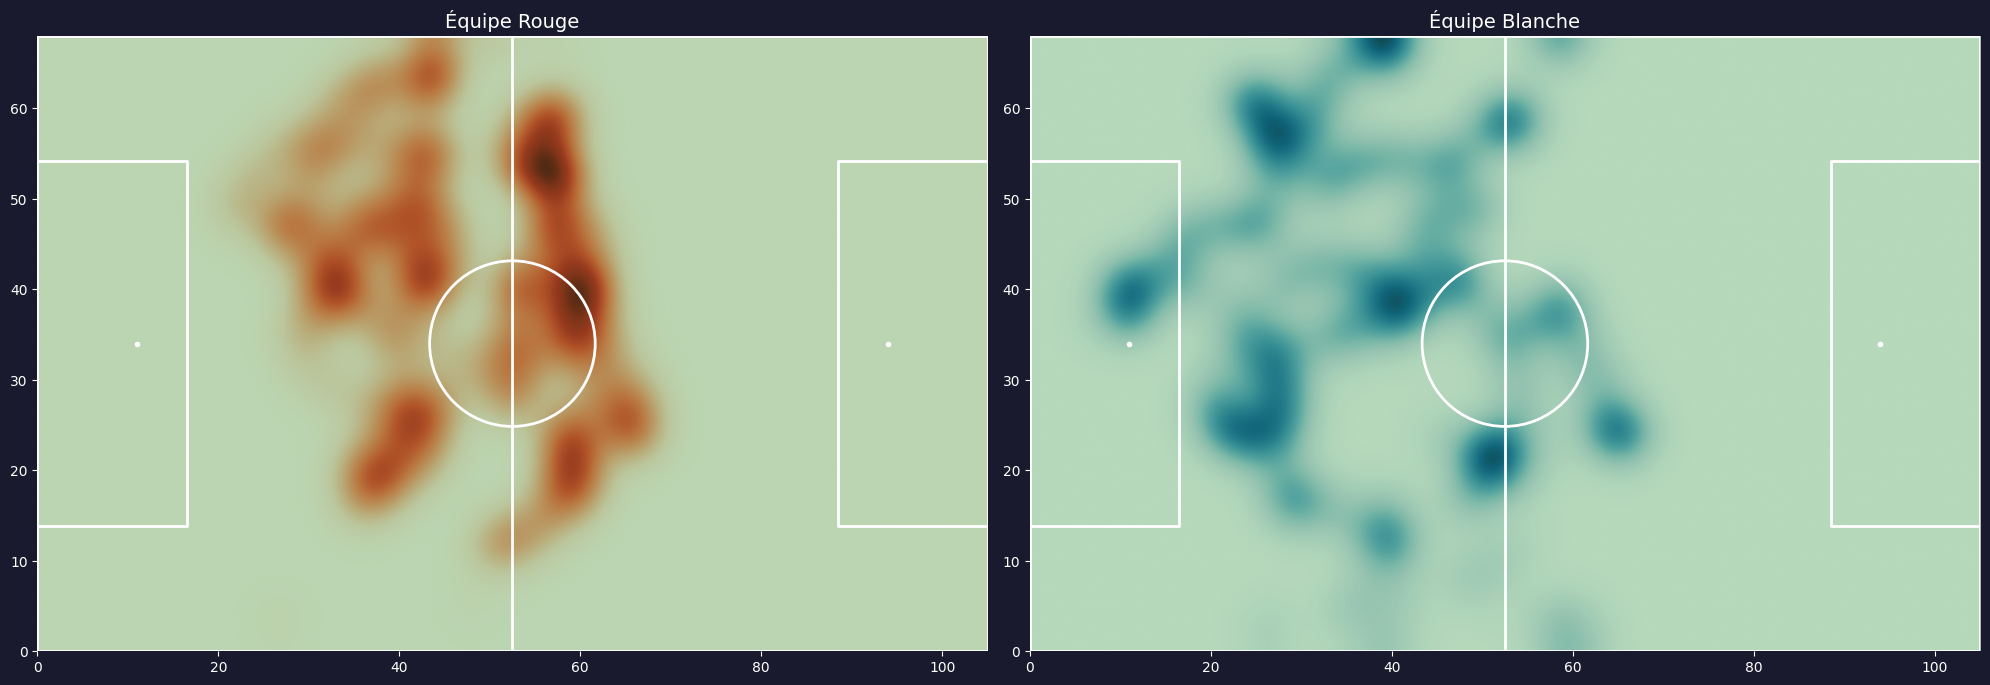

Heatmaps sauvegardées 


In [24]:
def draw_pitch_mpl(ax):
    ax.set_facecolor('#228B22')
    ax.set_xlim(0, 105)
    ax.set_ylim(0, 68)
    for spine in ax.spines.values():
        spine.set_visible(False)
    # Contours
    ax.plot([0,105,105,0,0], [0,0,68,68,0], 'w-', lw=2)
    # Ligne médiane
    ax.plot([52.5,52.5], [0,68], 'w-', lw=2)
    # Rond central
    circle = plt.Circle((52.5,34), 9.15, color='w', fill=False, lw=2)
    ax.add_patch(circle)
    # Surface gauche
    ax.plot([0,16.5,16.5,0], [13.84,13.84,54.16,54.16], 'w-', lw=2)
    # Surface droite
    ax.plot([105,88.5,88.5,105], [13.84,13.84,54.16,54.16], 'w-', lw=2)
    # Points de penalty
    ax.plot(11, 34, 'wo', ms=3)
    ax.plot(94, 34, 'wo', ms=3)

def make_heatmap(positions, title, color):
    heatmap = np.zeros((68*10, 105*10))
    for x, y in positions:
        px, py = int(x*10), int(y*10)
        if 0 <= px < 1050 and 0 <= py < 680:
            heatmap[py, px] += 1
    heatmap = gaussian_filter(heatmap, sigma=25)
    return heatmap

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, positions, title, cmap in zip(
    axes,
    [positions_team0, positions_team1],
    ['Équipe Rouge', 'Équipe Blanche'],
    ['Reds', 'Blues']
):
    draw_pitch_mpl(ax)
    heatmap = make_heatmap(positions, title, cmap)
    ax.imshow(heatmap, extent=[0,105,68,0], cmap=cmap, alpha=0.7)
    ax.set_title(title, color='white', fontsize=14)
    ax.tick_params(colors='white')
    fig.patch.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig('/kaggle/working/heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmaps sauvegardées ")

In [34]:
RETRAIN_BALL = False

if RETRAIN_BALL:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'roboflow'])

    from kaggle_secrets import UserSecretsClient
    from roboflow import Roboflow

    rf = Roboflow(api_key=UserSecretsClient().get_secret("ROBOFLOW_API_KEY"))
    project = rf.workspace("roboflow-jvuqo").project("football-ball-detection-rejhg")
    dataset = project.version(1).download("yolov8")

    ball = YOLO('yolov8x.pt')
    ball.train(data=f"{dataset.location}/data.yaml", epochs=50, imgsz=640, batch=16,
               name='ball_detector', patience=10, verbose=False)
    shutil.copy('/kaggle/working/runs/detect/ball_detector/weights/best.pt',
                '/kaggle/working/ball_detector_best.pt')

In [35]:
player_model = YOLO('yolov8x.pt')
ball_model = YOLO('/kaggle/input/models/yanisg/ball-detector/pytorch/default/1/ball_detector_best.pt')
tracker = sv.ByteTrack()

def get_jersey_color_hsv(frame, box):
    x1, y1, x2, y2 = map(int, box)
    h = y2 - y1
    w = x2 - x1
    crop = frame[y1 + int(h*0.1) : y1 + int(h*0.4),
                 x1 + int(w*0.15) : x2 - int(w*0.15)]
    if crop.size == 0:
        return [0, 0, 0]
    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV).reshape(-1, 3).astype(np.float32)
    mask = ~((hsv[:,0] > 35) & (hsv[:,0] < 85) & (hsv[:,1] > 40))
    filtered = hsv[mask]
    if len(filtered) < 5:
        return hsv.mean(axis=0)
    return filtered.mean(axis=0)

def draw_pitch():
    pitch = np.zeros((PITCH_H, PITCH_W, 3), dtype=np.uint8)
    pitch[:] = (34, 139, 34)
    cv2.rectangle(pitch, (0,0), (PITCH_W-1, PITCH_H-1), (255,255,255), 2)
    cv2.line(pitch, (525,0), (525,680), (255,255,255), 2)
    cv2.circle(pitch, (525,340), 91, (255,255,255), 2)
    cv2.rectangle(pitch, (0,138), (165,542), (255,255,255), 2)
    cv2.rectangle(pitch, (885,138), (1050,542), (255,255,255), 2)
    cv2.circle(pitch, (110,340), 5, (255,255,255), -1)
    return pitch

cap = cv2.VideoCapture(VIDEO_PATH)
fps    = int(cap.get(cv2.CAP_PROP_FPS))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = fps * 20

PITCH_W, PITCH_H = 1050, 680
MAP_W = int(width * 0.4)
MAP_H = int(MAP_W * PITCH_H / PITCH_W)
FINAL_W = width + MAP_W
FINAL_H = max(height, MAP_H)

out = cv2.VideoWriter(
    '/kaggle/working/output_final_v4.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (FINAL_W, FINAL_H)
)

DOT_COLORS = {arbitre_cluster: (0,255,255), non_arbitre[0]: (0,0,255), non_arbitre[1]: (255,255,255)}
BOX_COLORS  = {arbitre_cluster: (0,255,255), non_arbitre[0]: (0,0,255), non_arbitre[1]: (255,255,255)}

cap.set(cv2.CAP_PROP_POS_FRAMES, 375)
_, ref_frame = cap.read()
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ref_results = player_model(ref_frame, conf=0.3, verbose=False)[0]
ref_det = sv.Detections.from_ultralytics(ref_results)
ref_det = ref_det[ref_det.class_id == 0]
ref_colors = np.array([get_jersey_color_hsv(ref_frame, box) for box in ref_det.xyxy])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(ref_colors)

for i in range(total):
    ret, frame = cap.read()
    if not ret:
        break

    # Joueurs
    results = player_model(frame, conf=0.3, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = detections[detections.class_id == 0]
    detections = tracker.update_with_detections(detections)

    colors = np.array([get_jersey_color_hsv(frame, box) for box in detections.xyxy])
    labels = kmeans.predict(colors) if len(colors) > 0 else []

    # Ballon
    ball_results = ball_model(frame, conf=0.25, verbose=False)[0]
    ball_pos = None
    best_conf = 0
    for box in ball_results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf)
        cx, cy = (x1+x2)//2, (y1+y2)//2
        pt = np.array([[[float(cx), float(cy)]]], dtype=np.float32)
        terrain = cv2.perspectiveTransform(pt, H)[0][0]
        if 5 <= terrain[0] <= 100 and 2 <= terrain[1] <= 66:
            if conf > best_conf:
                best_conf = conf
                ball_pos = (cx, cy)

    # Annoter la frame
    annotated = frame.copy()
    for j, box in enumerate(detections.xyxy):
        x1, y1, x2, y2 = map(int, box)
        color = BOX_COLORS[labels[j]]
        cv2.rectangle(annotated, (x1,y1), (x2,y2), color, 2)
        cv2.putText(annotated, f"ID={detections.tracker_id[j]}",
                    (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    if ball_pos:
        cv2.circle(annotated, ball_pos, 8, (255,100,0), -1)
        cv2.circle(annotated, ball_pos, 8, (0,0,0), 2)

    # Mini-carte
    pitch = draw_pitch()
    if len(detections.xyxy) > 0:
        foot_points = []
        for box in detections.xyxy:
            x1, y1, x2, y2 = box
            foot_points.append([(x1+x2)/2, y2])
        foot_points = np.array(foot_points, dtype=np.float32).reshape(-1,1,2)
        projected = cv2.perspectiveTransform(foot_points, H)
        for j, pt in enumerate(projected):
            x, y = pt[0]
            px, py = int(x*10), int(y*10)
            if 0 <= px < PITCH_W and 0 <= py < PITCH_H:
                color = DOT_COLORS[labels[j]]
                cv2.circle(pitch, (px,py), 12, color, -1)
                cv2.circle(pitch, (px,py), 12, (0,0,0), 2)

    # Ballon sur mini-carte
    if ball_pos:
        ball_pt = np.array([[[float(ball_pos[0]), float(ball_pos[1])]]], dtype=np.float32)
        ball_terrain = cv2.perspectiveTransform(ball_pt, H)[0][0]
        bx, by = int(ball_terrain[0]*10), int(ball_terrain[1]*10)
        if 0 <= bx < PITCH_W and 0 <= by < PITCH_H:
            cv2.circle(pitch, (bx,by), 7, (255,100,0), -1)
            cv2.circle(pitch, (bx,by), 7, (0,0,0), 2)

    pitch_resized = cv2.resize(pitch, (MAP_W, MAP_H))
    composite = np.zeros((FINAL_H, FINAL_W, 3), dtype=np.uint8)
    composite[:height, :width] = annotated
    composite[:MAP_H, width:width+MAP_W] = pitch_resized
    out.write(composite)

    if i % 25 == 0:
        print(f"Frame {i}/{total}")

cap.release()
out.release()
print("Vidéo finale v4 sauvegardée ")

Frame 0/500
Frame 25/500
Frame 50/500
Frame 75/500
Frame 100/500
Frame 125/500
Frame 150/500
Frame 175/500
Frame 200/500
Frame 225/500
Frame 250/500
Frame 275/500
Frame 300/500
Frame 325/500
Frame 350/500
Frame 375/500
Frame 400/500
Frame 425/500
Frame 450/500
Frame 475/500
Vidéo finale v4 sauvegardée 


In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import models, transforms
from PIL import Image
from collections import defaultdict
import random

CROPS_DIR = '/kaggle/working/reid_crops'
shutil.rmtree(CROPS_DIR, ignore_errors=True)
os.makedirs(CROPS_DIR)

model = YOLO('yolov8x.pt')
tracker = sv.ByteTrack()

cap = cv2.VideoCapture(VIDEO_PATH)
fps = int(cap.get(cv2.CAP_PROP_FPS))
total = fps * 20

crop_index = defaultdict(list)

for i in range(total):
    ret, frame = cap.read()
    if not ret:
        break
    if i % 3 != 0:
        continue
    results = model(frame, conf=0.3, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = detections[detections.class_id == 0]
    detections = tracker.update_with_detections(detections)
    for box, tid in zip(detections.xyxy, detections.tracker_id):
        x1, y1, x2, y2 = map(int, box)
        if (x2 - x1) < 20 or (y2 - y1) < 40:
            continue
        crop = frame[max(y1, 0):y2, max(x1, 0):x2]
        if crop.size == 0:
            continue
        tdir = os.path.join(CROPS_DIR, str(int(tid)))
        os.makedirs(tdir, exist_ok=True)
        path = os.path.join(tdir, f'{i:05d}.jpg')
        cv2.imwrite(path, crop)
        crop_index[int(tid)].append(path)

cap.release()

crop_index = {t: sorted(p) for t, p in crop_index.items() if len(p) >= 8}
print(f"{len(crop_index)} tracks, {sum(len(p) for p in crop_index.values())} crops")

87 tracks, 2956 crops


In [37]:
train_tf = transforms.Compose([
    transforms.Resize((128, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3),
])

eval_tf = transforms.Compose([
    transforms.Resize((128, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class CropDataset(Dataset):
    def __init__(self, index, tf):
        self.samples = [(p, t) for t, paths in index.items() for p in paths]
        self.tf = tf

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, tid = self.samples[i]
        img = Image.open(path).convert('RGB')
        return self.tf(img), tid

class PKSampler(Sampler):
    def __init__(self, dataset, P=8, K=4):
        self.P, self.K = P, K
        self.by_track = defaultdict(list)
        for i, (_, t) in enumerate(dataset.samples):
            self.by_track[t].append(i)
        self.tracks = list(self.by_track)
        self.n_batches = len(dataset) // (P * K)

    def __iter__(self):
        for _ in range(self.n_batches):
            batch = []
            for t in random.sample(self.tracks, min(self.P, len(self.tracks))):
                idx = self.by_track[t]
                if len(idx) >= self.K:
                    batch += random.sample(idx, self.K)
                else:
                    batch += random.choices(idx, k=self.K)
            yield batch

    def __len__(self):
        return self.n_batches

In [38]:
class EmbeddingNet(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        backbone = models.resnet18(weights='IMAGENET1K_V1')
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.head = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, dim),
        )

    def forward(self, x):
        x = self.features(x).flatten(1)
        x = self.head(x)
        return F.normalize(x, dim=1)

def batch_hard_triplet_loss(emb, labels, margin=0.3):
    dist = torch.cdist(emb, emb)
    same = labels.unsqueeze(0) == labels.unsqueeze(1)
    pos_mask = same & ~torch.eye(len(labels), dtype=torch.bool, device=emb.device)
    hardest_pos = (dist * pos_mask).max(dim=1).values
    d = dist.clone()
    d[same] = float('inf')
    hardest_neg = d.min(dim=1).values
    return F.relu(hardest_pos - hardest_neg + margin).mean()

In [40]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

tracks = sorted(crop_index)
random.seed(42)
random.shuffle(tracks)
n_test = max(4, len(tracks) // 4)
test_tracks = set(tracks[:n_test])

train_index = {t: p for t, p in crop_index.items() if t not in test_tracks}
test_index = {t: p for t, p in crop_index.items() if t in test_tracks}
print(f"train : {len(train_index)} tracks, test : {len(test_index)} tracks jamais vus")

train_ds = CropDataset(train_index, train_tf)
loader = DataLoader(train_ds, batch_sampler=PKSampler(train_ds, P=8, K=4), num_workers=2)

net = EmbeddingNet().to(device)
opt = torch.optim.Adam([
    {'params': net.features.parameters(), 'lr': 1e-4},
    {'params': net.head.parameters(), 'lr': 1e-3},
])

for epoch in range(15):
    net.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = batch_hard_triplet_loss(net(imgs), labels)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"epoch {epoch+1:2d}  loss {total_loss/len(loader):.4f}")

torch.save(net.state_dict(), '/kaggle/working/reid_resnet18.pt')

train : 66 tracks, test : 21 tracks jamais vus
epoch  1  loss 0.3722
epoch  2  loss 0.3229
epoch  3  loss 0.2902
epoch  4  loss 0.2820
epoch  5  loss 0.2415
epoch  6  loss 0.2239
epoch  7  loss 0.1876
epoch  8  loss 0.1661
epoch  9  loss 0.1582
epoch 10  loss 0.1429
epoch 11  loss 0.1254
epoch 12  loss 0.1291
epoch 13  loss 0.1163
epoch 14  loss 0.0749
epoch 15  loss 0.1021


rank-1: 0.722 | rank-5: 0.970 (403 queries, 21 unseen players)


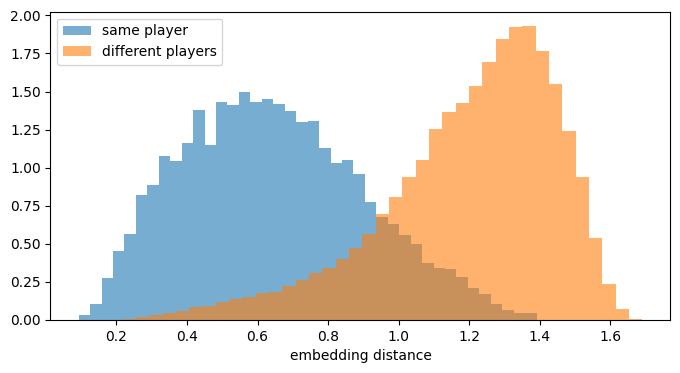

In [41]:
@torch.no_grad()
def embed_paths(paths, batch_size=64):
    net.eval()
    embs = []
    for k in range(0, len(paths), batch_size):
        batch = torch.stack([eval_tf(Image.open(p).convert('RGB')) for p in paths[k:k+batch_size]])
        embs.append(net(batch.to(device)).cpu())
    return torch.cat(embs)

query_paths, query_labels = [], []
gal_paths, gal_labels = [], []
for t, paths in test_index.items():
    mid = len(paths) // 2
    gal_paths += paths[:mid]
    gal_labels += [t] * mid
    query_paths += paths[mid:]
    query_labels += [t] * (len(paths) - mid)

q = embed_paths(query_paths)
g = embed_paths(gal_paths)
ql = torch.tensor(query_labels)
gl = torch.tensor(gal_labels)
dist = torch.cdist(q, g)

order = dist.argsort(dim=1)
hit1, hit5 = [], []
for qi in range(len(ql)):
    seen = []
    for gi in order[qi]:
        t = gl[gi].item()
        if t not in seen:
            seen.append(t)
        if len(seen) == 5:
            break
    hit1.append(ql[qi].item() == seen[0])
    hit5.append(ql[qi].item() in seen)

print(f"rank-1: {np.mean(hit1):.3f} | rank-5: {np.mean(hit5):.3f} "
      f"({len(ql)} queries, {len(test_index)} unseen players)")

same = ql.unsqueeze(1) == gl.unsqueeze(0)
plt.figure(figsize=(8, 4))
plt.hist(dist[same].numpy(), bins=40, alpha=0.6, density=True, label='same player')
plt.hist(dist[~same].numpy(), bins=40, alpha=0.6, density=True, label='different players')
plt.xlabel('embedding distance')
plt.legend()
plt.savefig('/kaggle/working/reid_distance_hist.png', dpi=150, bbox_inches='tight')
plt.show()

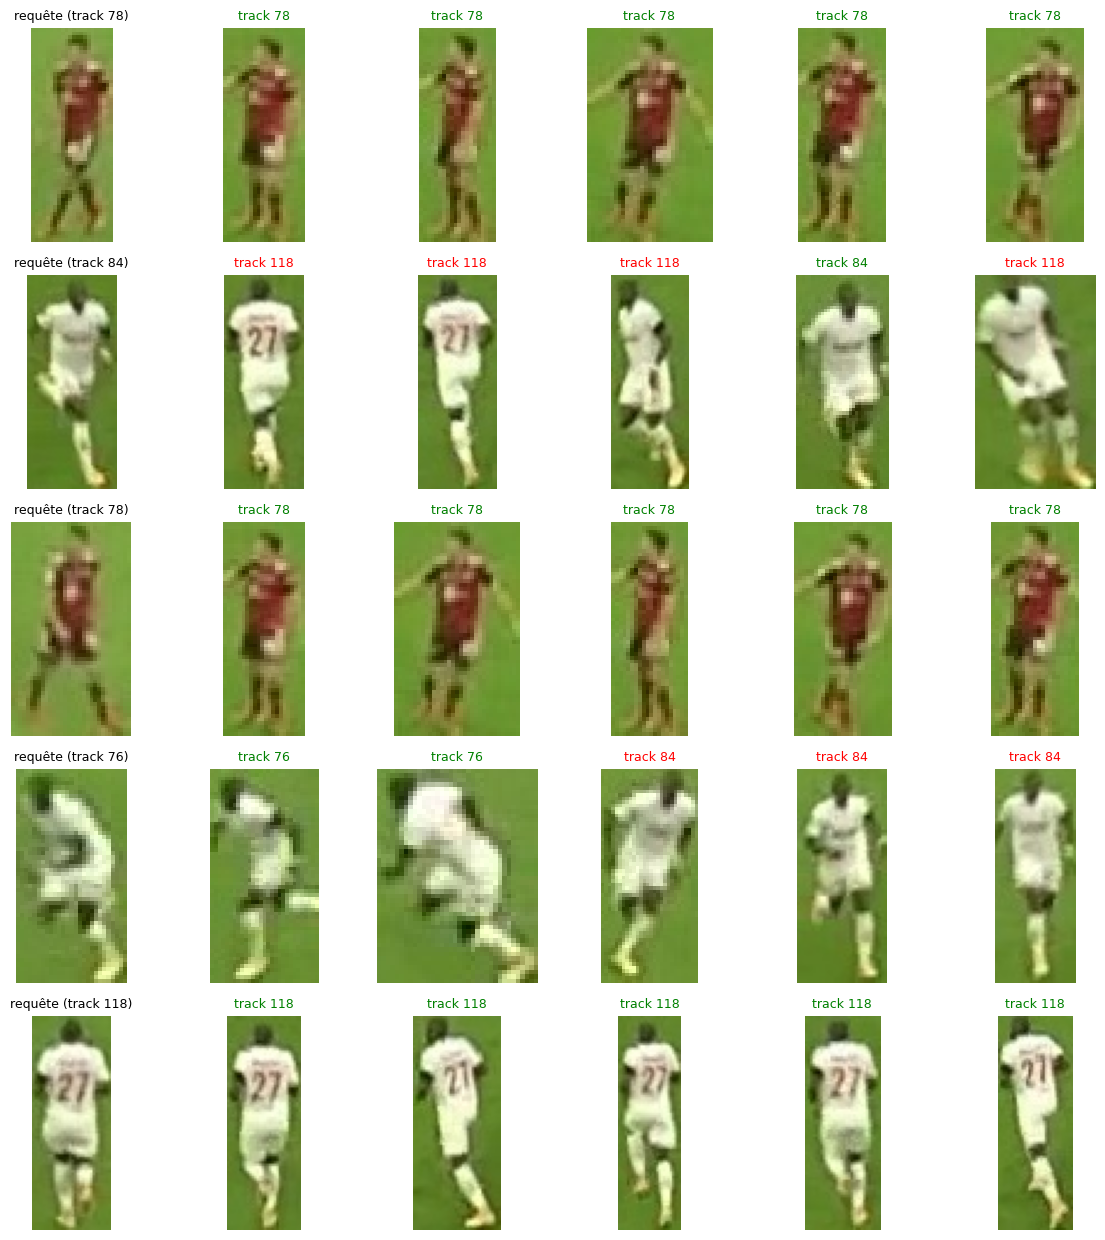

In [42]:
n_show = 5
sample_q = random.sample(range(len(query_paths)), n_show)

fig, axes = plt.subplots(n_show, 6, figsize=(12, 2.5 * n_show))
for row, qi in enumerate(sample_q):
    top5 = dist[qi].argsort()[:5]
    img = cv2.cvtColor(cv2.imread(query_paths[qi]), cv2.COLOR_BGR2RGB)
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"requête (track {query_labels[qi]})", fontsize=9)
    for col, gi in enumerate(top5):
        img = cv2.cvtColor(cv2.imread(gal_paths[gi]), cv2.COLOR_BGR2RGB)
        axes[row, col + 1].imshow(img)
        ok = gal_labels[gi] == query_labels[qi]
        axes[row, col + 1].set_title(f"track {gal_labels[gi]}", fontsize=9,
                                     color='green' if ok else 'red')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()